# Ratio preferences

Do our participants prefer 1:2 ratios or 1:3 ratios?

How to go about it:

We compare probability distributions of our participants' produced interval ratios to hypothetical
probability distributions.

Steps:

1. Calculate interval ratios for our participants' taps (this is already done in calculate_interval_ratios.py).
2. Generate hypothetical distributions
    - Use the same kde.factor as for the pp's
    - We need one for each specific ratio, e.g. one distribution for 0.25 (1:3 ratio), one for 0.75
    (3:1 ratio), etc.
3. Generate probability distributions (gaussian kde), with a specific kde.factor

4. Compare resulting distributions using e.g. a K-S test

## Preliminaries

In [2]:
# Imports
import thebeat
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
ratios = pd.read_csv(os.path.join('data', 'pilot', 'processed', 'interval_ratios.csv'))

## Hypothetical distributions

In [20]:
# Make random number generator
rand_rng = np.random.default_rng(seed=42)

# Create the x axis of the probability density plot
x = np.arange(0, 1, 0.001)

# Create the hypothetical distributions with some noise
hypothetical_distributions_functions = {
    'binary': scipy.stats.gaussian_kde(np.concatenate([rand_rng.normal(loc=1/3, scale=0.00005, size=5000), rand_rng.normal(loc=2/3, scale=0.00005, size=5000)])),
    'ternary': scipy.stats.gaussian_kde(np.concatenate([rand_rng.normal(loc=1/4, scale=0.00005, size=5000), rand_rng.normal(loc=3/4, scale=0.00005, size=5000)])),
}

hypothetical_distributions_y_values = {}

for label, kde in hypothetical_distributions_functions.items():
    hypothetical_distributions_y_values[label] = kde.evaluate(x)

Plots for understanding what's happening:

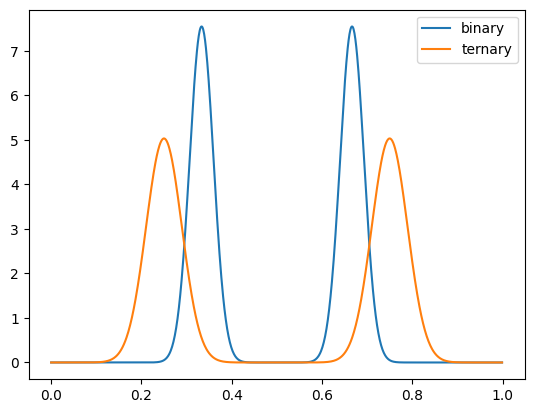

In [21]:
for hypo_distribution in hypothetical_distributions_y_values.keys():
    # Get the y values for the hypothetical distribution
    hypothetical_y_values = hypothetical_distributions_y_values[hypo_distribution]
    plt.plot(x, hypothetical_y_values, label=hypo_distribution)
plt.legend()
plt.show()

## Generate probability distributions and compare to hypothetical ones

In [15]:
ratio_preferences = pd.DataFrame()

for hypo_distribution in hypothetical_distributions_y_values.keys():
    # Get the y values for the hypothetical distribution
    hypothetical_y_values = hypothetical_distributions_y_values[hypo_distribution]
    for pp_id, pp_df in ratios.groupby('pp_id'):
        for tempo, tempo_df in pp_df.groupby('stim_tempo_intended'):
            for length, length_df in tempo_df.groupby('length'):
                # Calculate y values for the measured distribution
                measured_kde = scipy.stats.gaussian_kde(length_df.interval_ratio.values)
                measured_y_values = measured_kde.evaluate(x)

                # Do KS test
                ks = scipy.stats.ks_2samp(measured_y_values, hypothetical_y_values)

                # Make a little dataframe
                df_piece = pd.DataFrame({
                    'pp_id': pp_id,
                    'stim_tempo_intended': tempo,
                    'length': length,
                    'hypo_distribution': hypo_distribution,
                    'ks_statistic': ks.statistic
                }, index=[0])

                # Add to the big dataframe
                ratio_preferences = pd.concat([ratio_preferences, df_piece])

ratio_preferences = ratio_preferences.sort_values(by=['pp_id', 'stim_tempo_intended', 'length', 'hypo_distribution']).reset_index(drop=True)
ratio_preferences.hypo_distribution = ratio_preferences.hypo_distribution.astype('category')

# Write out
ratio_preferences.to_csv(os.path.join('data', 'pilot', 'processed', 'ratio_preferences_kstest.csv'), index=False)

Now we just need to find a way of visualizing this data. I guess we have 4 facets for each of
the conditions, 
and each hypothetical distribution has a different colour. Then just points for each of values.

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:712: UserWarning: Using the catplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/site-packages/seaborn/categorical.py:3025: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try stripplot
  warnings.warn(msg, UserWarning)


ValueError: Could not interpret value `hypo_distribution` for parameter `x`

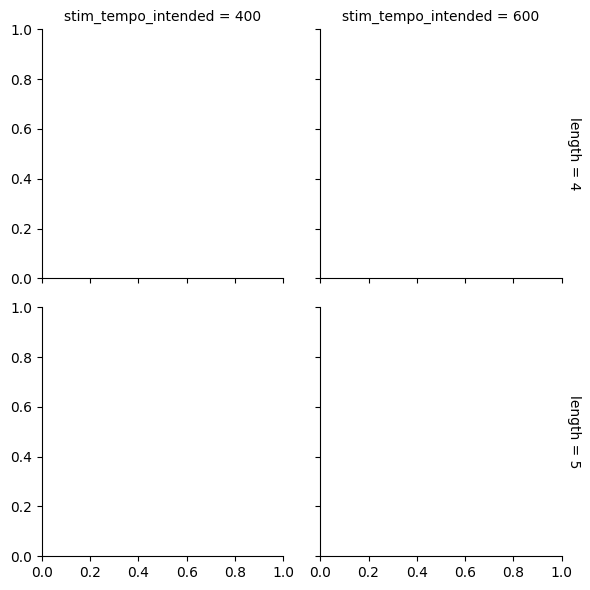

In [50]:
g = sns.FacetGrid(ratio_preferences, col="stim_tempo_intended", row="length", margin_titles=True)
g.map(sns.catplot, x="hypo_distribution", y="ks_statistic")